# Tensor Network Based Quantum Data Loading (Simplified)

Based on arXiv:2310.05897 - Encoding 16×16 MNIST images into quantum circuits using 8 qubits.

**This version uses PennyLane's StatePrep for direct amplitude encoding.**

**Pipeline:** Image → MPS Decomposition (for visualization) → StatePrep → IonQ

**For the full paper implementation** with explicit MPS → unitary gate conversion, see `tnn_paper.ipynb`.


In [1]:
# Install required packages (run once)
%pip install pennylane numpy torch torchvision matplotlib --quiet



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Core imports
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
import torch
from torchvision import datasets, transforms

# Configuration
IMAGE_SIZE = 16  # 16x16 = 256 pixels
N_QUBITS = 8     # 2^8 = 256 amplitudes

print(f'Image size: {IMAGE_SIZE}x{IMAGE_SIZE} = {IMAGE_SIZE**2} pixels')
print(f'Number of qubits: {N_QUBITS}')
print(f'PennyLane version: {qml.__version__}')


Image size: 16x16 = 256 pixels
Number of qubits: 8
PennyLane version: 0.42.3


In [3]:
# Load MNIST dataset at 16x16 resolution
transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

mnist_train = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
print(f'Dataset loaded: {len(mnist_train)} images')
print(f'Image shape: {mnist_train[0][0].shape}')


Dataset loaded: 60000 images
Image shape: torch.Size([1, 16, 16])


In [4]:
# Core functions

def compute_fidelity(state1, state2):
    """Compute quantum state fidelity |⟨ψ1|ψ2⟩|²"""
    return np.abs(np.vdot(state1, state2)) ** 2

def preprocess_image_for_quantum(image_tensor):
    """Convert image to normalized quantum state vector."""
    flat = image_tensor.flatten().numpy()
    if np.allclose(flat, 0):
        flat = np.ones_like(flat)
    return flat / np.linalg.norm(flat)

# ============================================================
# MPS decomposition (for visualization only)
# ============================================================

def state_to_mps(state_vector, n_qubits, max_bond_dim=None):
    """Convert state vector to MPS using sequential SVD."""
    tensor = state_vector.reshape([2] * n_qubits)
    mps_tensors = []
    bond_dim = 1
    
    for i in range(n_qubits - 1):
        remaining = n_qubits - i - 1
        matrix = tensor.reshape(bond_dim * 2, 2 ** remaining)
        
        U, S, Vh = np.linalg.svd(matrix, full_matrices=False)
        
        new_bond = len(S)
        if max_bond_dim is not None:
            new_bond = min(new_bond, max_bond_dim)
        
        U = U[:, :new_bond]
        S = S[:new_bond]
        Vh = Vh[:new_bond, :]
        
        mps_tensors.append(U.reshape(bond_dim, 2, new_bond))
        tensor = np.diag(S) @ Vh
        bond_dim = new_bond
    
    mps_tensors.append(tensor.reshape(bond_dim, 2, 1))
    return mps_tensors

def mps_to_state(mps_tensors):
    """Contract MPS tensors back to state vector."""
    result = mps_tensors[0]
    for tensor in mps_tensors[1:]:
        result = np.tensordot(result, tensor, axes=([-1], [0]))
    return result.squeeze().flatten()

def get_max_bond_dim(mps_tensors):
    """Get maximum bond dimension from MPS tensors."""
    return max([t.shape[2] for t in mps_tensors])

def mps_reconstruct_image(image_tensor, n_qubits, max_bond_dim=None):
    """Reconstruct image through MPS at given bond dimension."""
    state_vector = preprocess_image_for_quantum(image_tensor)
    mps_tensors = state_to_mps(state_vector, n_qubits, max_bond_dim=max_bond_dim)
    reconstructed = mps_to_state(mps_tensors)
    
    norm = np.linalg.norm(reconstructed)
    if norm > 0:
        reconstructed = reconstructed / norm
    
    fidelity = compute_fidelity(state_vector, reconstructed)
    img_size = int(np.sqrt(len(reconstructed)))
    return np.abs(reconstructed).reshape(img_size, img_size), fidelity, get_max_bond_dim(mps_tensors)

print('✓ Core functions defined')


✓ Core functions defined


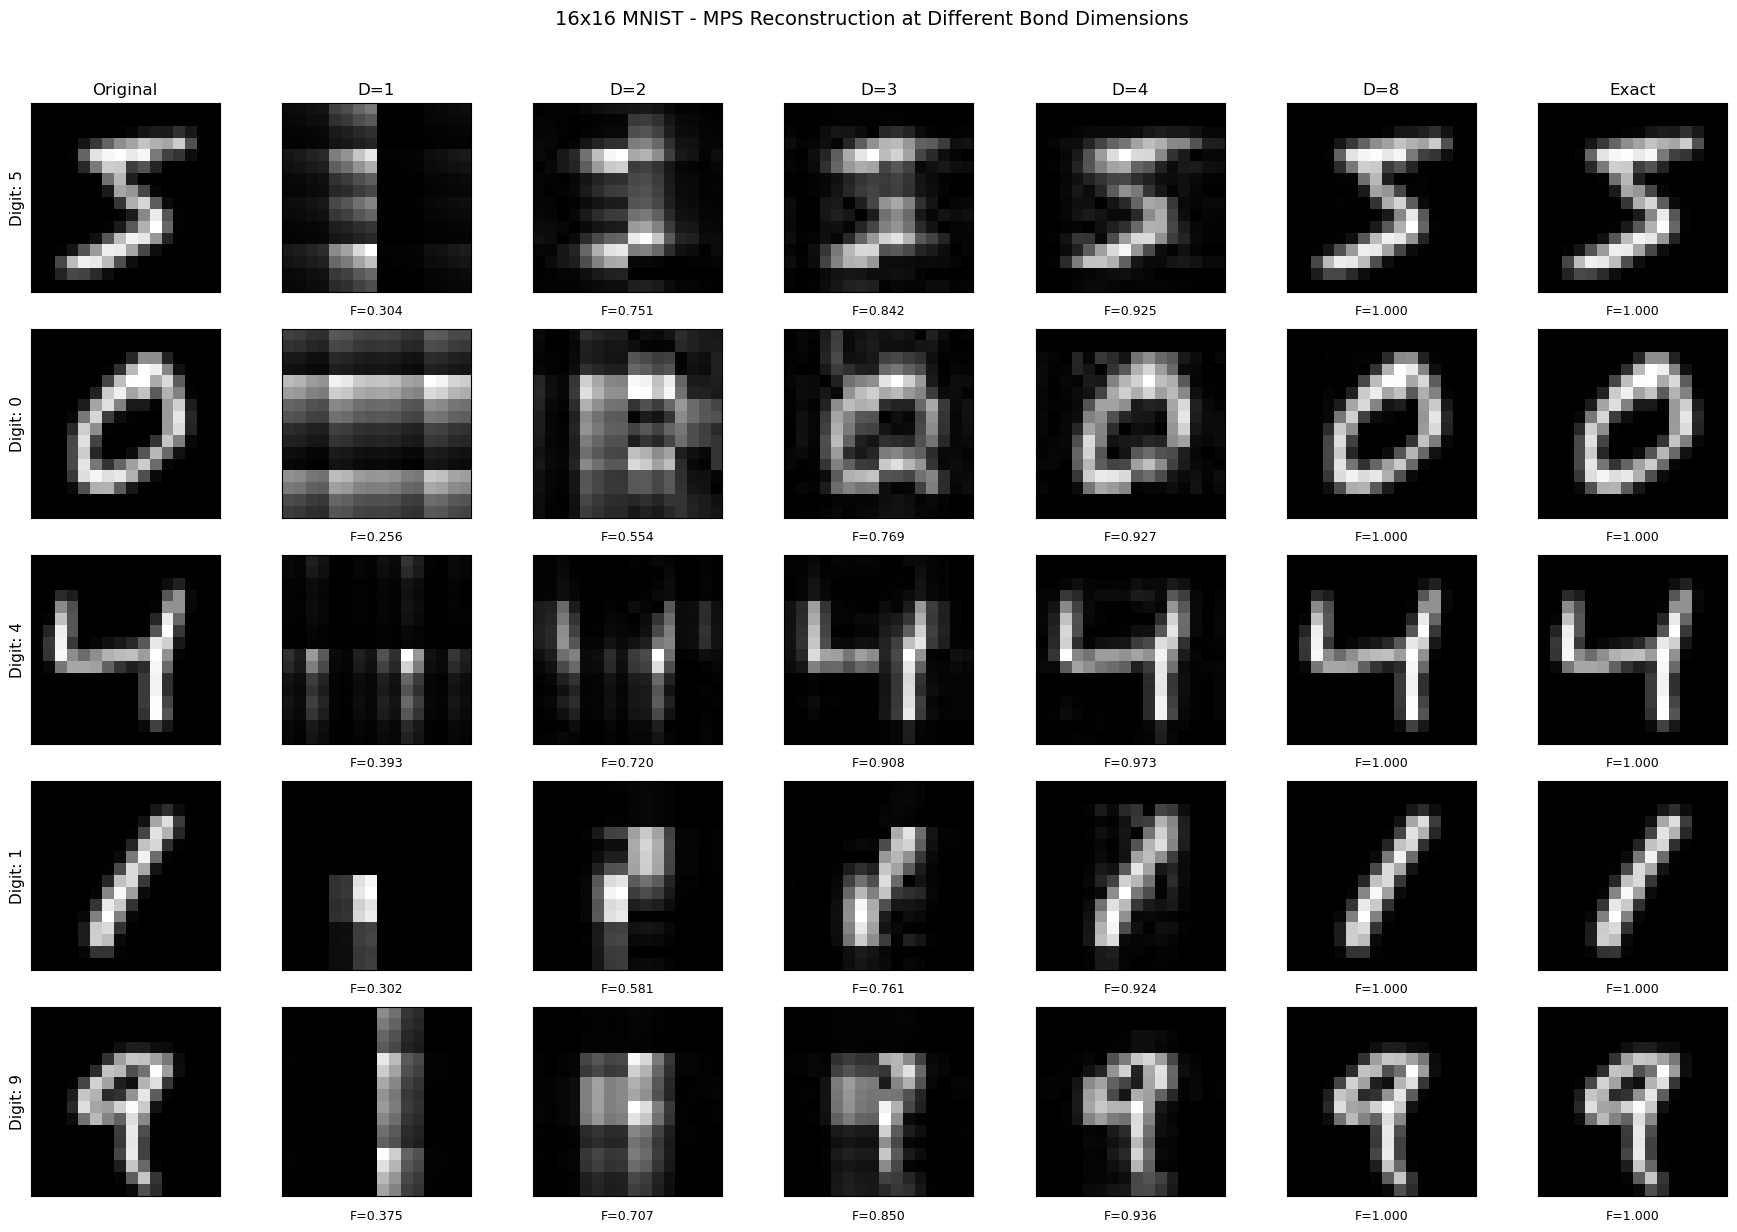

Lower D = simpler representation, lower fidelity
Higher D = more complex representation, better reconstruction


In [5]:
# Paper Figure 3 Style: MPS Reconstruction at Different Bond Dimensions

n_images = 5
bond_dims = [1, 2, 3, 4, 8, None]

fig, axes = plt.subplots(n_images, len(bond_dims) + 1, figsize=(18, 12))

for row in range(n_images):
    img, label = mnist_train[row]
    
    # Original
    original = img.squeeze().numpy()
    original_norm = original / np.linalg.norm(original.flatten())
    axes[row, 0].imshow(np.abs(original_norm), cmap='gray')
    if row == 0:
        axes[row, 0].set_title('Original', fontsize=12)
    axes[row, 0].set_ylabel(f'Digit: {label}', fontsize=11)
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])
    
    # Reconstructions
    for col, max_D in enumerate(bond_dims):
        recon, fidelity, actual_D = mps_reconstruct_image(img, N_QUBITS, max_bond_dim=max_D)
        axes[row, col + 1].imshow(recon, cmap='gray')
        if row == 0:
            axes[row, col + 1].set_title('Exact' if max_D is None else f'D={max_D}', fontsize=12)
        axes[row, col + 1].set_xticks([])
        axes[row, col + 1].set_yticks([])
        axes[row, col + 1].text(0.5, -0.12, f'F={fidelity:.3f}', 
                                 transform=axes[row, col + 1].transAxes, ha='center', fontsize=9)

plt.suptitle('16x16 MNIST - MPS Reconstruction at Different Bond Dimensions', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print('Lower D = simpler representation, lower fidelity')
print('Higher D = more complex representation, better reconstruction')


## Quantum Circuit with StatePrep

This simplified approach uses PennyLane's `qml.StatePrep` to directly encode the image as quantum amplitudes.

**Advantages:**
- Simple and straightforward
- Perfect fidelity (no approximation)
- PennyLane handles the circuit decomposition

**Note:** This is different from the paper's MPS-based circuit construction, but achieves the same goal of encoding the image into a quantum state.


In [6]:
# Quantum Circuit using StatePrep (Direct Amplitude Encoding)

def build_quantum_circuit(image_tensor, n_qubits):
    """
    Build quantum circuit that encodes image using StatePrep.
    
    Args:
        image_tensor: PyTorch tensor of image
        n_qubits: Number of qubits (2^n_qubits = number of pixels)
    
    Returns:
        circuit: PennyLane QNode
        state_vector: Target state vector
    """
    state_vector = preprocess_image_for_quantum(image_tensor)
    dev = qml.device('default.qubit', wires=n_qubits)
    
    @qml.qnode(dev)
    def circuit():
        qml.StatePrep(state_vector, wires=range(n_qubits))
        return qml.state()
    
    return circuit, state_vector

# Test
test_img, test_label = mnist_train[0]
circuit, sv = build_quantum_circuit(test_img, N_QUBITS)
output = circuit()

print('=' * 50)
print('QUANTUM CIRCUIT VERIFICATION')
print('=' * 50)
print(f'Image: {IMAGE_SIZE}x{IMAGE_SIZE} = {IMAGE_SIZE**2} pixels')
print(f'Qubits: {N_QUBITS}')
print(f'Fidelity: {compute_fidelity(sv, output):.6f}')
print('=' * 50)


QUANTUM CIRCUIT VERIFICATION
Image: 16x16 = 256 pixels
Qubits: 8
Fidelity: 1.000000


In [7]:
# Test on multiple images
print('Testing StatePrep encoding on first 10 images:')
print('=' * 50)

for i in range(10):
    img, label = mnist_train[i]
    circuit, sv = build_quantum_circuit(img, N_QUBITS)
    fid = compute_fidelity(sv, circuit())
    print(f'Image {i} (Label: {label}): Fidelity = {fid:.6f}')

print('=' * 50)
print('All images encoded with perfect fidelity!')


Testing StatePrep encoding on first 10 images:
Image 0 (Label: 5): Fidelity = 1.000000
Image 1 (Label: 0): Fidelity = 1.000000
Image 2 (Label: 4): Fidelity = 1.000000
Image 3 (Label: 1): Fidelity = 1.000000
Image 4 (Label: 9): Fidelity = 1.000000
Image 5 (Label: 2): Fidelity = 1.000000
Image 6 (Label: 1): Fidelity = 1.000000
Image 7 (Label: 3): Fidelity = 1.000000
Image 8 (Label: 1): Fidelity = 1.000000
Image 9 (Label: 4): Fidelity = 1.000000
All images encoded with perfect fidelity!
